In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sqlalchemy import create_engine
import pymysql

In [2]:
from tqdm.auto import tqdm
tqdm.pandas()

In [3]:
username = "root"
password = ""
port = 3306
database = "common"

In [4]:
engine = create_engine('mysql+pymysql://%s@localhost:%i/%s' %(username, port, database))

In [34]:
sql = "SELECT * FROM common.histone_count WHERE histone_total_count > 0"
histone_count_df = pd.read_sql_query(sql, engine)

display(histone_count_df.head())
display(histone_count_df.shape)

,h_chrom,tss_start,tss_end,h_chromStart,h_chromEnd,h_gene,h_test_id,h_gene_id,h_locus,h_sample_1,...,n_cdsStartStat,n_cdsEndStat,n_exonFrames,tss,H3K4me3,H3K9ac,H3K9me3,H3K27ac,H3K27me3,histone_total_count
0,chr1,4470110,4474110,4472110,4484744,LOC284661,XLOC_000053,XLOC_000053,chr1:4472110-4484744,hepg2_hr2,...,none,none,"b'-1,-1,-1,-1,-1,-1,'",4472110,0,0,0,0,1,1
1,chr1,17183516,17187516,17185443,17185516,MIR3675,XLOC_001399,XLOC_001399,chr1:17185443-17185516,hepg2_hr2,...,none,none,"b'-1,'",17185516,1,0,0,0,0,1
2,chr1,31710734,31714734,31652591,31712734,NKAIN1,XLOC_001503,XLOC_001503,chr1:31652591-31712734,hepg2_hr2,...,cmpl,cmpl,"b'2,1,0,0,0,0,0,'",31712734,1,0,0,0,0,1
3,chr1,45767581,45771581,45769581,45771291,LOC400752,XLOC_000380,XLOC_000380,chr1:45769581-45771291,hepg2_hr2,...,none,none,"b'-1,'",45769581,6,7,0,5,0,18
4,chr1,53066042,53070042,53068042,53074723,GPX7,XLOC_000416,XLOC_000416,chr1:53068042-53074723,hepg2_hr2,...,cmpl,cmpl,"b'0,0,1,'",53068042,2,4,0,1,0,7


(580, 42)

In [35]:
histone_count_df.describe()

,tss_start,tss_end,h_chromStart,h_chromEnd,h_value_1,h_value_2,h_test_stat,h_p_value,h_q_value,n_txStart,...,n_exonCount,n_exonStarts,n_exonEnds,tss,H3K4me3,H3K9ac,H3K9me3,H3K27ac,H3K27me3,histone_total_count
count,5.800000e+02,5.800000e+02,5.800000e+02,5.800000e+02,580.000000,580.000000,580.000000,580.000000,580.000000,5.800000e+02,...,580.000000,5.800000e+02,5.800000e+02,5.800000e+02,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000
mean,7.347893e+07,7.348293e+07,7.344472e+07,7.349208e+07,18.613056,18.473565,-0.003956,0.837735,0.999820,7.344472e+07,...,6.794828,1.636343e+09,1.636344e+09,7.348093e+07,3.118966,2.405172,0.151724,1.796552,0.518966,7.991379
std,5.208582e+07,5.208582e+07,5.207927e+07,5.208906e+07,170.142575,167.131877,0.445514,0.254850,0.000214,5.207927e+07,...,6.741025,8.947080e+08,8.947075e+08,5.208582e+07,3.544143,2.774727,0.421053,2.390248,1.171621,7.767893
min,1.947600e+05,1.987600e+05,1.967600e+05,2.002580e+05,0.000000,0.000000,-3.016100,0.004350,0.999565,1.967600e+05,...,1.000000,5.738070e+05,5.758850e+05,1.967600e+05,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,3.532245e+07,3.532645e+07,3.532312e+07,3.533139e+07,0.000000,0.000000,0.000000,0.742313,0.999565,3.532312e+07,...,2.000000,2.147484e+09,2.147484e+09,3.532445e+07,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,5.688660e+07,5.689060e+07,5.688860e+07,5.691754e+07,0.072035,0.076970,0.000000,1.000000,1.000000,5.688860e+07,...,5.000000,2.147484e+09,2.147484e+09,5.688860e+07,2.000000,1.000000,0.000000,1.000000,0.000000,4.000000
75%,1.096692e+08,1.096732e+08,1.096712e+08,1.096776e+08,5.639733,4.915693,0.000000,1.000000,1.000000,1.096712e+08,...,10.000000,2.147484e+09,2.147484e+09,1.096712e+08,6.000000,4.000000,0.000000,3.000000,1.000000,14.000000
max,2.485101e+08,2.485141e+08,2.485121e+08,2.485130e+08,3781.020000,3699.890000,1.878220,1.000000,1.000000,2.485121e+08,...,41.000000,2.147484e+09,2.147484e+09,2.485121e+08,13.000000,13.000000,4.000000,11.000000,8.000000,37.000000


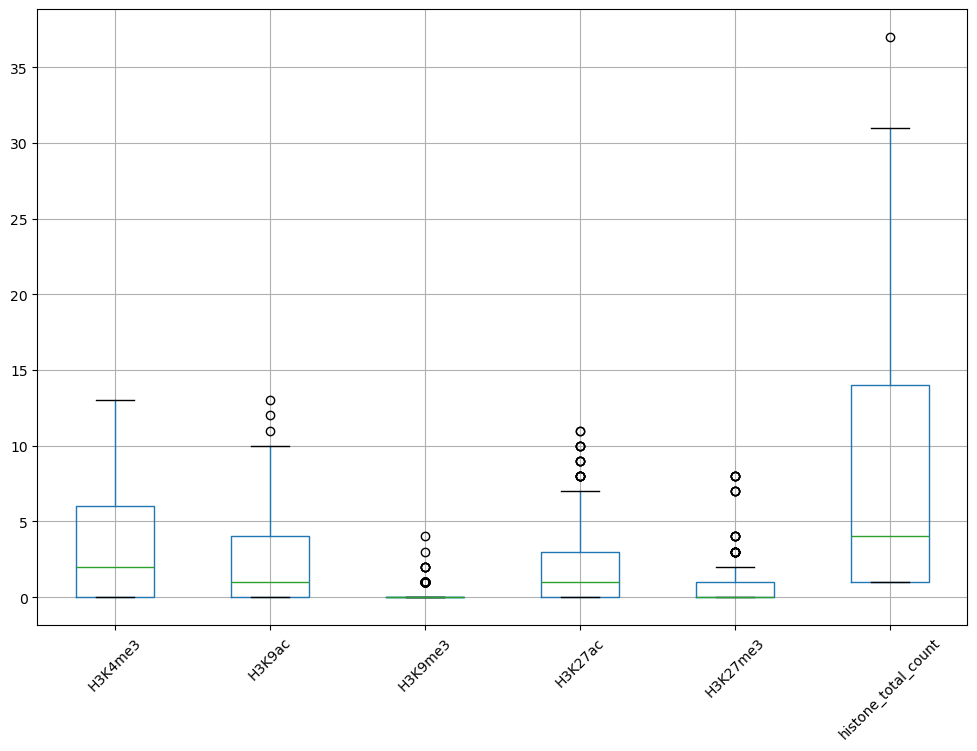

In [37]:
plt.figure(figsize=(12, 8))
histone_count_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3', 'histone_total_count']].boxplot()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

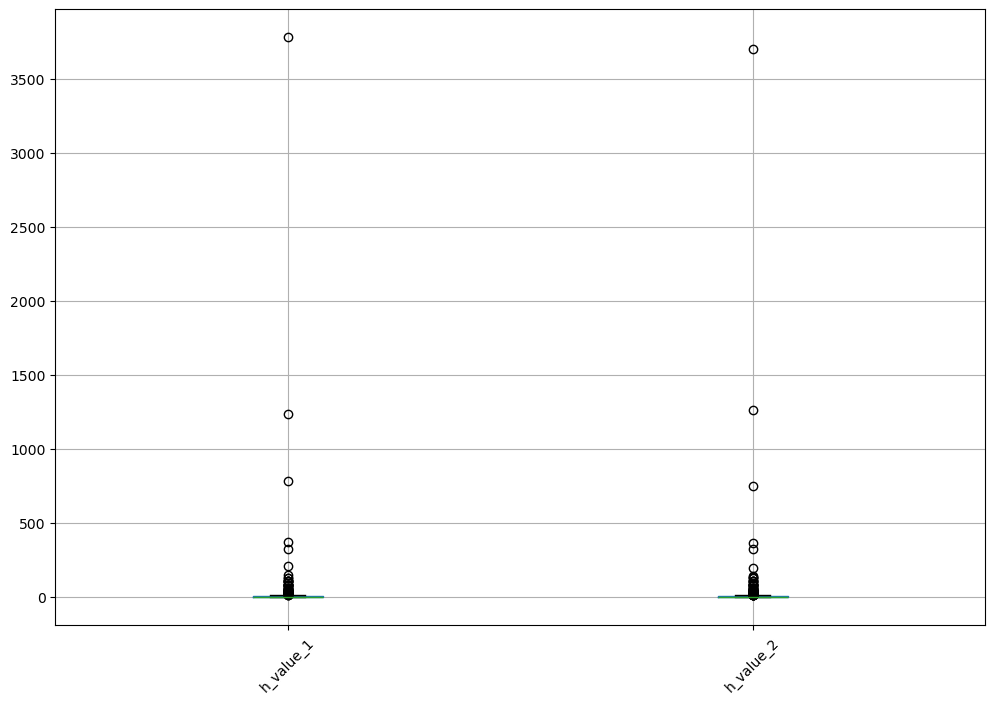

In [38]:
plt.figure(figsize=(12, 8))
histone_count_df[['h_value_1', 'h_value_2']].boxplot()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

In [6]:
histone_count_df.columns

Index(['h_chrom', 'tss_start', 'tss_end', 'h_chromStart', 'h_chromEnd',
       'h_gene', 'h_test_id', 'h_gene_id', 'h_locus', 'h_sample_1',
       'h_sample_2', 'h_status', 'h_value_1', 'h_value_2',
       'h_log2(fold_change)', 'h_test_stat', 'h_p_value', 'h_q_value',
       'h_significant', 'n_chrom', 'n_txStart', 'n_txEnd', 'n_name2',
       'n_score', 'n_bin', 'n_name', 'n_strand', 'n_cdsStart', 'n_cdsEnd',
       'n_exonCount', 'n_exonStarts', 'n_exonEnds', 'n_cdsStartStat',
       'n_cdsEndStat', 'n_exonFrames', 'tss', 'H3K4me3', 'H3K9ac', 'H3K9me3',
       'H3K27ac', 'H3K27me3', 'histone_total_count'],
      dtype='object')

In [39]:
X = histone_count_df[['H3K4me3', 'H3K9ac', 'H3K9me3',
       'H3K27ac', 'H3K27me3', 'histone_total_count']]
y = histone_count_df[['h_value_1']]

display(X.head())
display(y.head())

,H3K4me3,H3K9ac,H3K9me3,H3K27ac,H3K27me3,histone_total_count
0,0,0,0,0,1,1
1,1,0,0,0,0,1
2,1,0,0,0,0,1
3,6,7,0,5,0,18
4,2,4,0,1,0,7


,h_value_1
0,0.000000
1,0.000000
2,0.108210
3,0.303308
4,6.906390


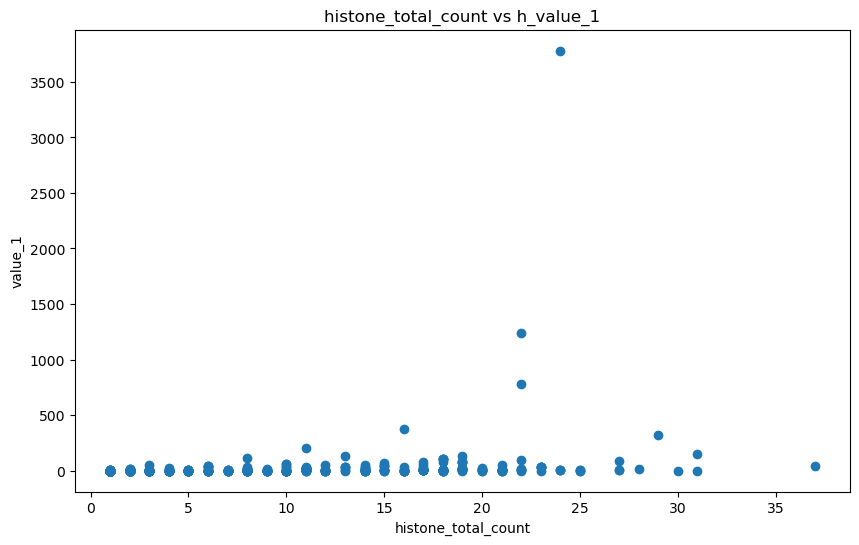

In [48]:
plt.figure(figsize=(10, 6))
plt.scatter(X['histone_total_count'], y['h_value_1'])
plt.xlabel('histone_total_count')
plt.ylabel('value_1')
plt.title('histone_total_count vs h_value_1')
plt.show()

In [49]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [50]:
# Create a linear regression model
model = LinearRegression()

In [51]:
# Train the model on the training set
model.fit(X_train, y_train)

LinearRegression()

In [52]:
# Make predictions on the test set
y_pred = model.predict(X_test)

In [45]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

Mean Squared Error: 1819.9776175217219
R^2 Score: -0.1011282477022295


In [46]:
display(y_test)

,h_value_1
575,0.000000
277,9.686640
104,0.000000
177,0.055301
456,0.000000
...,...
542,0.000000
299,0.000000
165,0.027144
272,9.686640


In [47]:
display(y_pred)

array([[ -7.35317577],
       [ 20.89645855],
       [-10.16240155],
       [-15.08517366],
       [ -7.35317577],
       [100.77600507],
       [ -7.35317577],
       [ -9.00523969],
       [-12.81664791],
       [ 20.80486264],
       [ -7.35317577],
       [ -6.47477489],
       [ -0.96328298],
       [  1.89174075],
       [ 86.21087657],
       [ 67.49441718],
       [ 31.9901015 ],
       [ -8.74330064],
       [ -4.15822938],
       [ 86.21087657],
       [ -6.47477489],
       [ 36.91287361],
       [-10.16240155],
       [ -3.77250876],
       [ -3.2798285 ],
       [ -6.47477489],
       [  6.30501068],
       [ -0.96328298],
       [168.01902618],
       [ -6.47477489],
       [ -7.35317577],
       [ 15.88984986],
       [ -2.40142762],
       [-12.81664791],
       [ -6.47477489],
       [  5.12837024],
       [ -6.47477489],
       [-11.65948606],
       [  5.89981147],
       [ -4.15822938],
       [ -7.35317577],
       [ 68.26585842],
       [ 15.78289022],
       [141